# Terrain and context: a hillside in winter

**Question:** how many hours of direct sun does a housing area on a hillside get in winter,
and how much does a ridge across the valley take away?

The site is a made-up slope near Innsbruck: a valley floor in the south, then a slope of
about 18 % that rises to the north, with a small spur. Twenty houses stand on the slope.
A 70 m ridge stands across the valley, about 75 m south of the site.

**Steps**
1. Make the terrain mesh and the houses. The houses stand at z = 0; the SDK seats them on the terrain.
2. Make the ridge as context geometry. Context geometry gives shade but gets no values.
3. Run direct sun hours for December to February, without and with the ridge.
4. Compare the two maps, then draw the result on the terrain in 3D.

Docs: [Your inputs](https://infrared.city/docs/sdk/#your-inputs) and
[Context geometry: the 1.0 limit](https://infrared.city/docs/sdk/#context-geometry-the-10-limit).

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from infrared_sdk import InfraredClient, SolarModelRequest
from infrared_sdk.analyses.types import AnalysesName
from infrared_sdk.models import TimePeriod

import ir_site as site
import ir_view3d as v3

os.environ.setdefault("INFRARED_QUIET", "1")  # no SDK progress lines in the notebook
logging.getLogger("infrared_sdk.sdk").setLevel(logging.ERROR)  # no "default base URL" note
client = InfraredClient()  # reads INFRARED_API_KEY
OUT = Path("outputs")

## 1. Terrain and houses

The terrain is a triangle mesh in the same metre frame as the buildings. It is larger than the
site, so that the slope around the site also gives shade. The limit is 500,000 triangles in one
request; `run_area` cuts the terrain for each tile.

`terrain_alignment="auto-align"` seats each house on the terrain below it. So you can give the
houses with their base at z = 0, as on a flat site.

In [2]:
LON, LAT = 11.395, 47.272          # south-west corner of the site
SIZE = 300.0                       # the site is 300 m x 300 m
polygon = site.rect_polygon(LON, LAT, SIZE, SIZE)


def ground_z(x, y):
    """Flat valley floor (y < 0), then an 18 % slope to the north, with a spur at x = 150 m."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    return 0.18 * np.clip(y, 0, None) + 10 * np.exp(-((x - 150) / 70) ** 2) * np.clip(y / SIZE, 0, 1)


xs = ys = np.arange(-150, SIZE + 151, 5.0)          # 5 m mesh, 150 m around the site
terrain = {"terrain": site.terrain_mesh(xs, ys, ground_z(*np.meshgrid(xs, ys)))}

houses = {}
for row, y in enumerate((60, 115, 170, 225)):       # four rows on the slope
    for col, x in enumerate(np.arange(45, 270, 45) + (row % 2) * 20):
        houses[f"house-{row}{col}"] = site.box(x - 7, y - 5, x + 7, y + 5, 0, 8.0)
print(f"{len(houses)} houses, terrain {len(terrain['terrain']['indices']) // 3:,} triangles")

20 houses, terrain 28,800 triangles


## 2. The ridge (context geometry)

Context geometry only gives shade. Only sky view factor, solar radiation, direct sun hours,
daylight availability and the interior models take it. In SDK 1.0 a context mesh reaches only
128 m past a tile: an object farther away is not sent, with no error. Keep far geometry simple
and low-poly.

In [3]:
ridge = {"ridge": site.box(-60, -110, SIZE + 60, -75, 0, 70.0)}  # 420 m long, 70 m high

## 3. Direct sun hours, December to February

One `TimePeriod` can wrap the year: 1 Dec to 28 Feb is one window. Direct sun hours need
a location and a time window, but no weather file.

In [4]:
winter = TimePeriod(start_month=12, start_day=1, start_hour=8, end_month=2, end_day=28, end_hour=17)


def sun_hours(context=None):
    return SolarModelRequest(
        analysis_type=AnalysesName.direct_sun_hours,
        latitude=LAT, longitude=LON, time_period=winter,
        ground_geometry=terrain,
        terrain_alignment="auto-align",
        context_geometry=context,
    )


for name, ctx in (("open", None), ("ridge", ridge)):
    p = client.preview_area(polygon, payload=sun_hours(ctx), buildings=houses)
    print(f"{name:6s} tiles {p.tile_count}, jobs {p.would_bill_jobs}, cost {p.estimated_cost_tokens} tokens")

open   tiles 1, jobs 1, cost 10 tokens
ridge  tiles 1, jobs 1, cost 10 tokens


In [5]:
grids = {}
for name, ctx in (("open", None), ("ridge", ridge)):
    result = client.run_area_and_wait(sun_hours(ctx), polygon, buildings=houses)
    # 1 m cells, row 0 = south. The grid covers the whole tile; keep the site.
    grids[name] = result.physical_grid()[: int(SIZE), : int(SIZE)]
    print(f"{name:6s} mean {np.nanmean(grids[name]):.0f} h, max {np.nanmax(grids[name]):.0f} h")

open   mean 768 h, max 811 h


ridge  mean 591 h, max 811 h


## 4. With and without the ridge

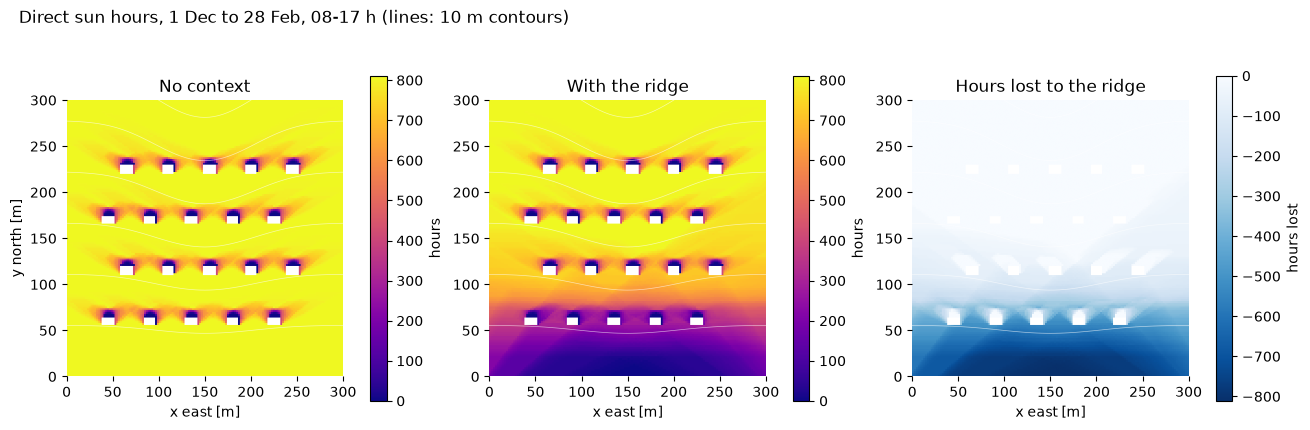

In [6]:
top = float(np.nanmax(grids["open"]))
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4), constrained_layout=True)
panels = [("open", "No context", grids["open"], "plasma", (0, top)),
          ("ridge", "With the ridge", grids["ridge"], "plasma", (0, top)),
          ("delta", "Hours lost to the ridge", grids["ridge"] - grids["open"], "Blues_r", (-top, 0))]
for ax, (key, title, grid, cmap, (lo, hi)) in zip(axes, panels):
    im = ax.imshow(grid, origin="lower", cmap=cmap, vmin=lo, vmax=hi, extent=(0, SIZE, 0, SIZE))
    ax.contour(xs, ys, ground_z(*np.meshgrid(xs, ys)), levels=np.arange(0, 80, 10),
               colors="white", linewidths=0.5, alpha=0.6)  # 10 m contour lines
    ax.set(title=title, xlim=(0, SIZE), ylim=(0, SIZE), xlabel="x east [m]")
    ax.set_frame_on(False)
    fig.colorbar(im, ax=ax, shrink=0.8, label="hours" if key != "delta" else "hours lost")
axes[0].set_ylabel("y north [m]")
fig.suptitle("Direct sun hours, 1 Dec to 28 Feb, 08-17 h (lines: 10 m contours)", x=0.01, ha="left")
plt.show()

**What you see:** without context, nearly the whole slope gets full winter sun; only short
shadows lie north of each house. With the ridge, the valley floor and the lower slope lose most
of their sun hours. Higher up the slope, the sun clears the ridge and the loss gets smaller.

## 5. On the terrain, in 3D

For the picture we lift each house onto the terrain, as `auto-align` does on the server.

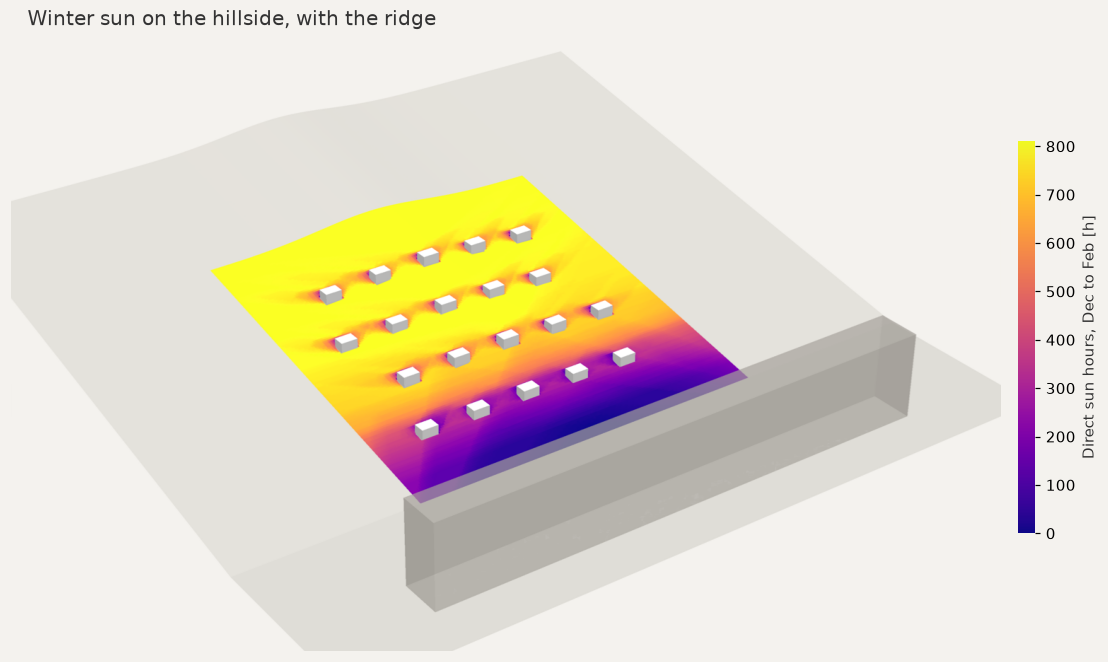

In [7]:
X, Y = np.meshgrid(np.arange(SIZE) + 0.5, np.arange(SIZE) + 0.5)
surface = v3.grid_surface(grids["ridge"], z=ground_z(X, Y))
lifted = {}
for key, mesh in houses.items():
    c = np.reshape(mesh["coordinates"], (-1, 3)).copy()
    c[:, 2] += ground_z(c[:, 0].mean(), c[:, 1].mean()) - 0.5  # base 0.5 m into the ground
    lifted[key] = {"coordinates": c.ravel(), "indices": mesh["indices"]}

pl = v3.plotter()
v3.add_meshes(pl, v3.mesh_from_dicts(terrain), color="#d6d3cb")
v3.add_meshes(pl, v3.mesh_from_dicts(ridge), opacity=0.45)
v3.add_values(pl, surface, cmap="plasma", clim=(0, top))
v3.add_meshes(pl, v3.mesh_from_dicts(lifted), color="#f5f5f4")
v3.show(pl, OUT / "07_sun_hours_3d.png", cmap="plasma", clim=(0, top),
        label="Direct sun hours, Dec to Feb [h]", title="Winter sun on the hillside, with the ridge",
        azimuth=-35, elevation=30, zoom=1.9, focus=(150, 110, 25))

**What you see:** the ridge (half transparent, in front) puts the foot of the slope in shade.
The upper rows of houses keep their winter sun.

## Next steps

- Use your own terrain: any triangle mesh in the metre frame of your site (make a mesh from a
  height map first). Wind analyses take no terrain.
- Try `terrain_alignment="assume-aligned"` when your buildings already sit on this terrain: the
  server then checks them and moves nothing.
- Sky view factor, solar radiation and daylight availability take the same `context_geometry`.